# <span style="color:#0097b2">0. Data</span>
[Back to TOC](#toc)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Libraries Importation</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Data Importation</h3>

In [2]:
df_eng = pd.read_csv('../data/engagement_based_perspective_clusters.csv', index_col='Loyalty#')
df_beh = pd.read_csv('../data/behvioral_segment_data.csv', index_col='Loyalty#')
df_val = pd.read_csv('../data/value_based_perspective_clusters.csv', index_col='Loyalty#')

# <span style="color:#0097b2">1. Data Preparation & Label Extraction</span>
[Back to TOC](#toc)

In [3]:
df_merged = df_val.copy()

# Add missing columns from Behavior DF
cols_to_add_beh = df_beh.columns.difference(df_merged.columns)
df_merged = df_merged.join(df_beh[cols_to_add_beh])

# Add missing columns from Engagement DF
cols_to_add_eng = df_eng.columns.difference(df_merged.columns)
df_merged = df_merged.join(df_eng[cols_to_add_eng])

In [4]:
df_merged

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,seg_Fragile_Value_Contributers,seg_Premium_driven_value,seg_Active_Redeemers,seg_From_September_to_December_travelers,seg_Holiday_travelers,seg_No_Flights,seg_Active_Travelers,seg_Dormant_Travelers,seg_Low_Engagement,seg_Non_Travelers
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,1,0,0,0,0,1,0,0,0,1
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,1,0,0,0,0,1,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,1,0,0,0,0,1,0,0,0,1
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,1,0,0,0,0,1,0,0,0,1
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,1,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,1,0,0,0,0,1,0,0,0,1
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,1,0,0,0,0,1,0,0,0,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,1,0,0,0,0,1,0,0,0,1


In [5]:
def get_cluster_label(df):
    """Helper to convert One-Hot/Dummy segment columns back to a single label"""
    # Filter columns that start with the segment prefix
    
    # If explicit cluster column exists (e.g. 'km_cluster'), use that. 
    # Otherwise, reverse the One-Hot encoding.


    # Fallback: look for standard cluster columns if OHE isn't used
    possible_cols = [c for c in df.columns if 'cluster' in c.lower()]
    if possible_cols:
        return df[possible_cols[0]]
    return None

In [7]:
# 3. Extract and Rename Labels for the 3 Perspectives
# (Adjust the 'prefix' logic if your specific notebook used different names)
df_merged['Value_Label'] = get_cluster_label(df_val)
df_merged['Behavior_Label'] = get_cluster_label(df_beh)
df_merged['Engagement_Label'] = get_cluster_label(df_eng) 

In [8]:
df_merged

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,seg_From_September_to_December_travelers,seg_Holiday_travelers,seg_No_Flights,seg_Active_Travelers,seg_Dormant_Travelers,seg_Low_Engagement,seg_Non_Travelers,Value_Label,Behavior_Label,Engagement_Label
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,0,1,0,0,0,1,1,1,1
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,0,1,0,0,0,1,4,4,4
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,0,1,0,0,0,1,5,5,5
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,0,1,0,0,0,1,3,3,3
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,0,1,0,0,0,1,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,0,1,0,0,0,1,4,4,4
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,0,1,0,0,0,1,1,1,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,0,1,0,0,0,1,3,3,3


In [9]:
# Drop rows where any label is missing (intersection only)
df_merged.dropna(subset=['Value_Label', 'Behavior_Label', 'Engagement_Label'], inplace=True)

print("Merged Data Shape:", df_merged.shape)
print(df_merged[['Value_Label', 'Behavior_Label', 'Engagement_Label']].head())

Merged Data Shape: (16695, 71)
          Value_Label  Behavior_Label  Engagement_Label
Loyalty#                                               
100011              1               1                 1
100012              4               4                 4
100013              5               5                 5
100014              3               3                 3
100015              4               4                 4


# <span style="color:#0097b2">2. Micro-Segmentation Strategy</span>
[Back to TOC](#toc)

In [10]:
df_merged['Micro_Segment'] = (
    df_merged['Engagement_Label'].astype(str) + " | " + 
    df_merged['Behavior_Label'].astype(str)
)

print(f"Number of Micro-Segments formed: {df_merged['Micro_Segment'].nunique()}")

Number of Micro-Segments formed: 9


In [11]:
features_to_exclude = ['Micro_Segment', 'Engagement_Label', 'Behavior_Label'] 
# Add any OHE columns to exclusion list
features_to_exclude += [c for c in df_merged.columns if c.startswith('seg_')]

metric_features = [c for c in df_merged.columns if c not in features_to_exclude]

# Calculate Centroids (Mean of features per micro-segment)
df_centroids = df_merged.groupby('Micro_Segment')[metric_features].mean()

# Scale the centroids before Hierarchical Clustering
# This is crucial because Value fields (Income) have different scales than Behavior fields (Frequency)
scaler = StandardScaler()
centroids_scaled = scaler.fit_transform(df_centroids)
df_centroids_scaled = pd.DataFrame(
    centroids_scaled, 
    index=df_centroids.index, 
    columns=df_centroids.columns
)

# <span style="color:#0097b2">3. Hierarchical Clustering (The Merge)</span>
[Back to TOC](#toc)

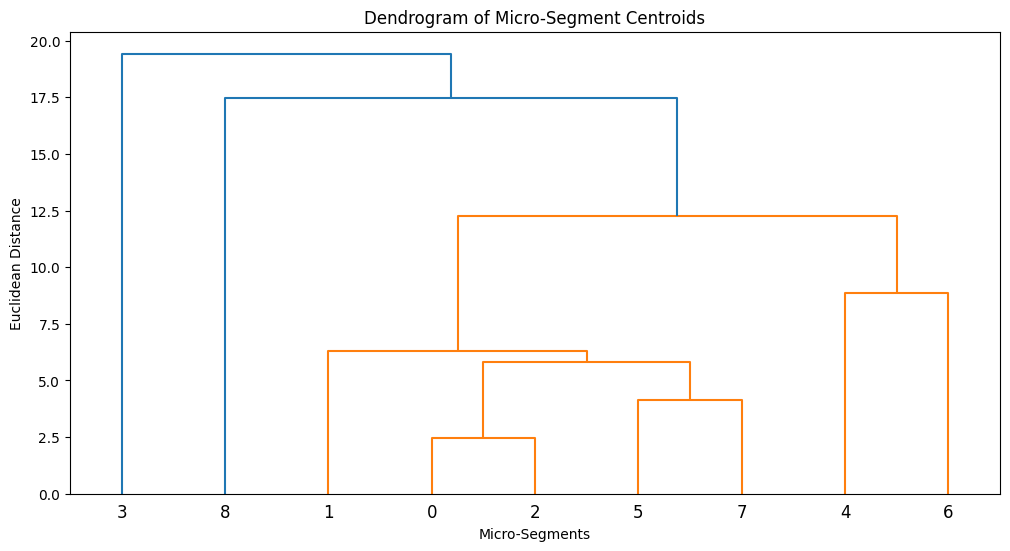

In [12]:
plt.figure(figsize=(12, 6))
plt.title('Dendrogram of Micro-Segment Centroids')
dendrogram = dendrogram(linkage(df_centroids_scaled, method='ward'))
plt.xlabel('Micro-Segments')
plt.ylabel('Euclidean Distance')
plt.show()

In [14]:
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
df_centroids['Final_Cluster_Label'] = hc.fit_predict(df_centroids_scaled)

In [15]:
# Create a mapping dictionary: Micro-Segment -> Final Cluster
micro_to_final_map = df_centroids['Final_Cluster_Label'].to_dict()

# Map the final cluster back to the main customer dataframe
df_merged['Final_Solution_Label'] = df_merged['Micro_Segment'].map(micro_to_final_map)

In [17]:
print("Final Segment Distribution:")
print(df_merged['Final_Solution_Label'].value_counts().sort_index())

# Display a sample of how perspectives were merged
print("\nSample mapping of Perspectives to Final Solution:")
print(df_merged[['Engagement_Label', 'Behavior_Label', 'Micro_Segment', 'Final_Solution_Label']].head(10))

Final Segment Distribution:
Final_Solution_Label
0    10704
1     3782
2     1517
3        2
4      690
Name: count, dtype: int64

Sample mapping of Perspectives to Final Solution:
              Engagement_Label         Behavior_Label  \
Loyalty#                                                
100011       seg_Non_Travelers         seg_No_Flights   
100012       seg_Non_Travelers         seg_No_Flights   
100013       seg_Non_Travelers         seg_No_Flights   
100014       seg_Non_Travelers         seg_No_Flights   
100015       seg_Non_Travelers         seg_No_Flights   
100016       seg_Non_Travelers         seg_No_Flights   
100017       seg_Non_Travelers         seg_No_Flights   
100018    seg_Active_Travelers  seg_Holiday_travelers   
100102    seg_Active_Travelers  seg_Holiday_travelers   
100140    seg_Active_Travelers  seg_Holiday_travelers   

                                         Micro_Segment  Final_Solution_Label  
Loyalty#                                               

# <span style="color:#0097b2">4. Profiling & Interpretation</span>
[Back to TOC](#toc)

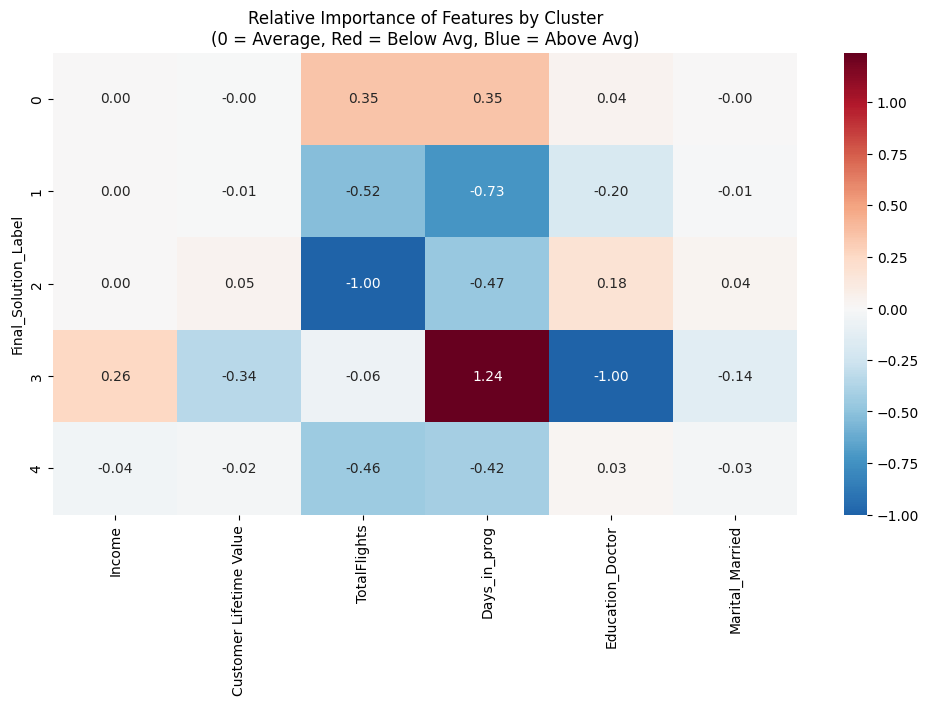

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the features you want to profile
# Include both Value (Income, CLV) and Behavior (Flights, Days_in_prog) metrics
profile_features = [
    'Income', 'Customer Lifetime Value', 'TotalFlights', 
    'Days_in_prog', 'Education_Doctor', 'Marital_Married'
] 
# Note: Add any other specific numeric columns you want to check

# 2. Calculate the Mean for each Cluster
cluster_means = df_merged.groupby('Final_Solution_Label')[profile_features].mean()

# 3. Calculate the Global Mean (Population Average)
global_means = df_merged[profile_features].mean()

# 4. Calculate Relative Importance 
# Formula: (Cluster Mean / Global Mean) - 1
# Result: 0.5 means "50% higher than average", -0.2 means "20% lower than average"
relative_imp = (cluster_means / global_means) - 1

# 5. Plot the Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(data=relative_imp, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Relative Importance of Features by Cluster\n(0 = Average, Red = Below Avg, Blue = Above Avg)')
plt.show()